<a href="https://colab.research.google.com/github/Uzema/dsp-seminars/blob/nikolaev_lab5/seminars/5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №5
## Основные характеристики цифровых фильтров

## Импорт библиотек

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import savgol_filter, savgol_coeffs, group_delay
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Вспомогательная функция для построения частотных характеристик
def plot_filter_response(b, a, fs=1000, title=''):
    """Строит АЧХ (линейный и дБ), ФЧХ и групповую задержку фильтра"""
    w, H = signal.freqz(b, a, fs=fs)
    mag_dB = 20*np.log10(np.abs(H) + 1e-12)
    phase = np.unwrap(np.angle(H))
    w_gd, gd = signal.group_delay((b, a), fs=fs)

    plt.figure(figsize=(12,10))
    plt.subplot(4,1,1)
    plt.semilogy(w, np.abs(H))
    plt.title(f'АЧХ (линейный масштаб) – {title}')
    plt.grid()
    plt.subplot(4,1,2)
    plt.plot(w, mag_dB)
    plt.title('АЧХ (дБ)')
    plt.ylabel('|H| (дБ)')
    plt.grid()
    plt.subplot(4,1,3)
    plt.plot(w, phase)
    plt.title('ФЧХ')
    plt.ylabel('Фаза (рад)')
    plt.grid()
    plt.subplot(4,1,4)
    plt.plot(w_gd, gd)
    plt.title('Групповая задержка')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Задержка (отсчёты)')
    plt.grid()
    plt.tight_layout()
    plt.show()


## Часть 1. КИХ-фильтр: скользящее среднее

**Скользящее среднее** – простейший КИХ-фильтр. Его коэффициенты: `b_k = 1/M` для `k = 0,...,M-1`. Фильтр имеет линейную фазу.

### Задание 1.1. Импульсная и переходная характеристики

Для длины окна `M = 5`:
1. Сформируйте массив коэффициентов `b` (нормированный).
2. Создайте тестовые сигналы: единичный импульс (длиной 20 отсчётов) и единичный скачок (длиной 50 отсчётов).
3. Примените фильтр с помощью `signal.lfilter(b, a, x)`, где `a = [1]`.
4. Постройте импульсную и переходную характеристики.


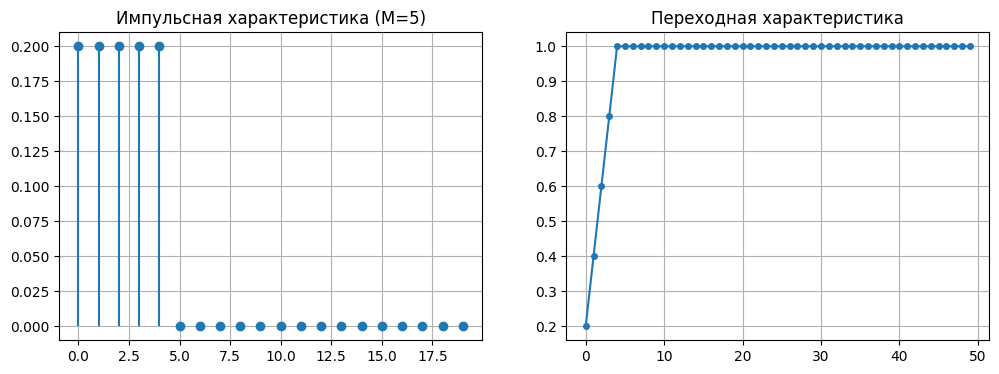

In [14]:
# Ваш код здесь
M = 5
b = np.ones(M) / M
a = [1]

# Импульс
impulse = np.zeros(20)
impulse[0] = 1

# Скачок
step = np.ones(50)
h = signal.lfilter(b, a, impulse) # Импульсная характеристика
s = signal.lfilter(b, a, step)    # Переходная характеристика

# Построение
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.stem(h , basefmt=" ") # Ваш код здесь: подставить h
plt.title(f'Импульсная характеристика (M={M})')
plt.grid()

plt.subplot(1,2,2)
plt.plot(s, 'o-', markersize=4) # Ваш код здесь: подставить s
plt.title('Переходная характеристика')
plt.grid()

plt.show()

**Вопрос:** Почему импульсная характеристика имеет конечную длину, а переходная выходит на постоянный уровень?


**Ответ:**
Импульсная характеристика конечна, потому что у фильтра короткая память, которая со временем очищается. Переходная характеристика стабилизируется, потому что с отсчета M в окно фильтра на каждом шаге заходит одна единица и одна выходит, поэтому сумма внутри окна перестает меняться.

### Задание 1.2. АЧХ и ФЧХ

Используя функцию `plot_filter_response`, постройте характеристики для скользящего среднего с длинами окон `M = 5`, `M = 10`, `M = 20`.


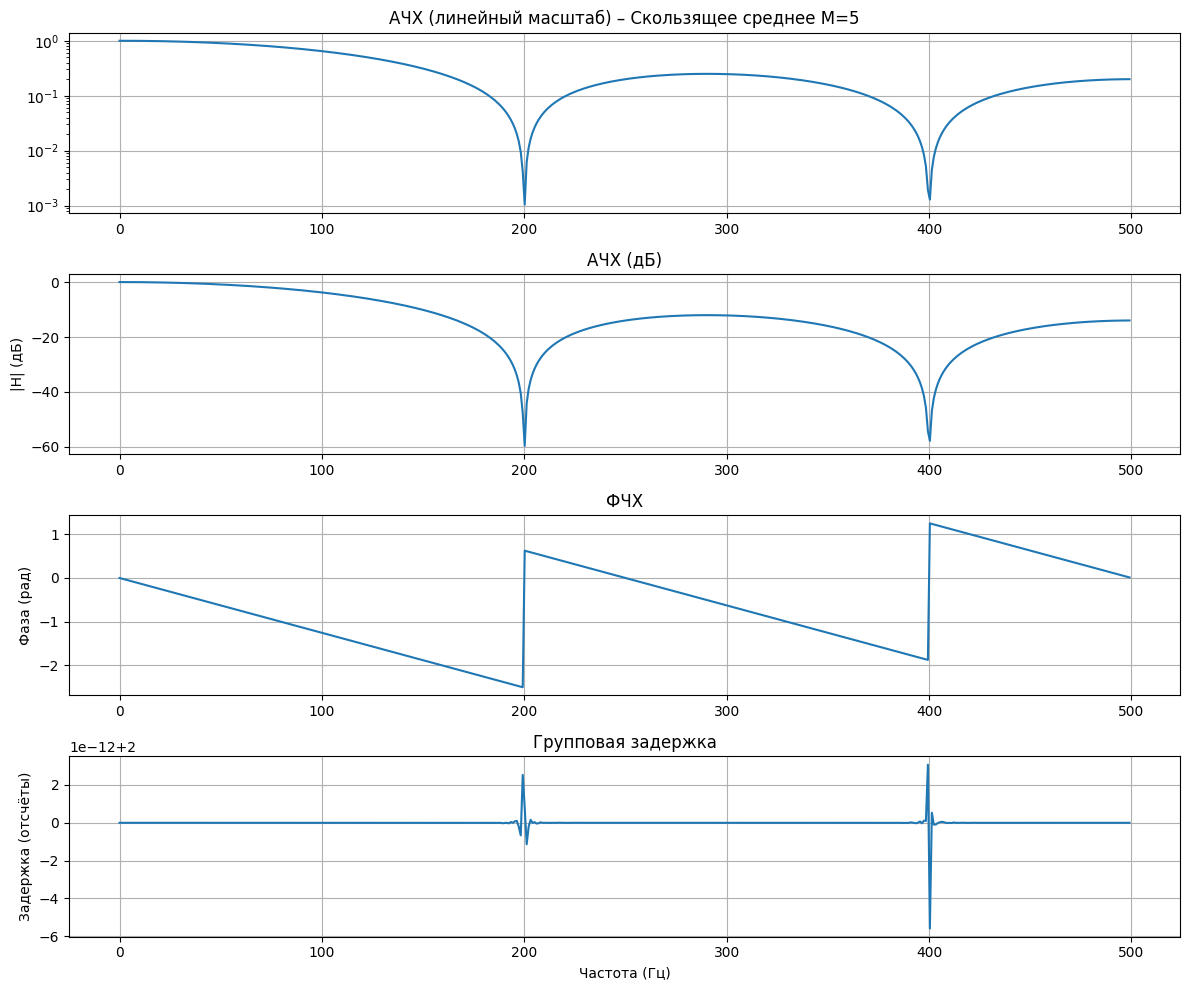

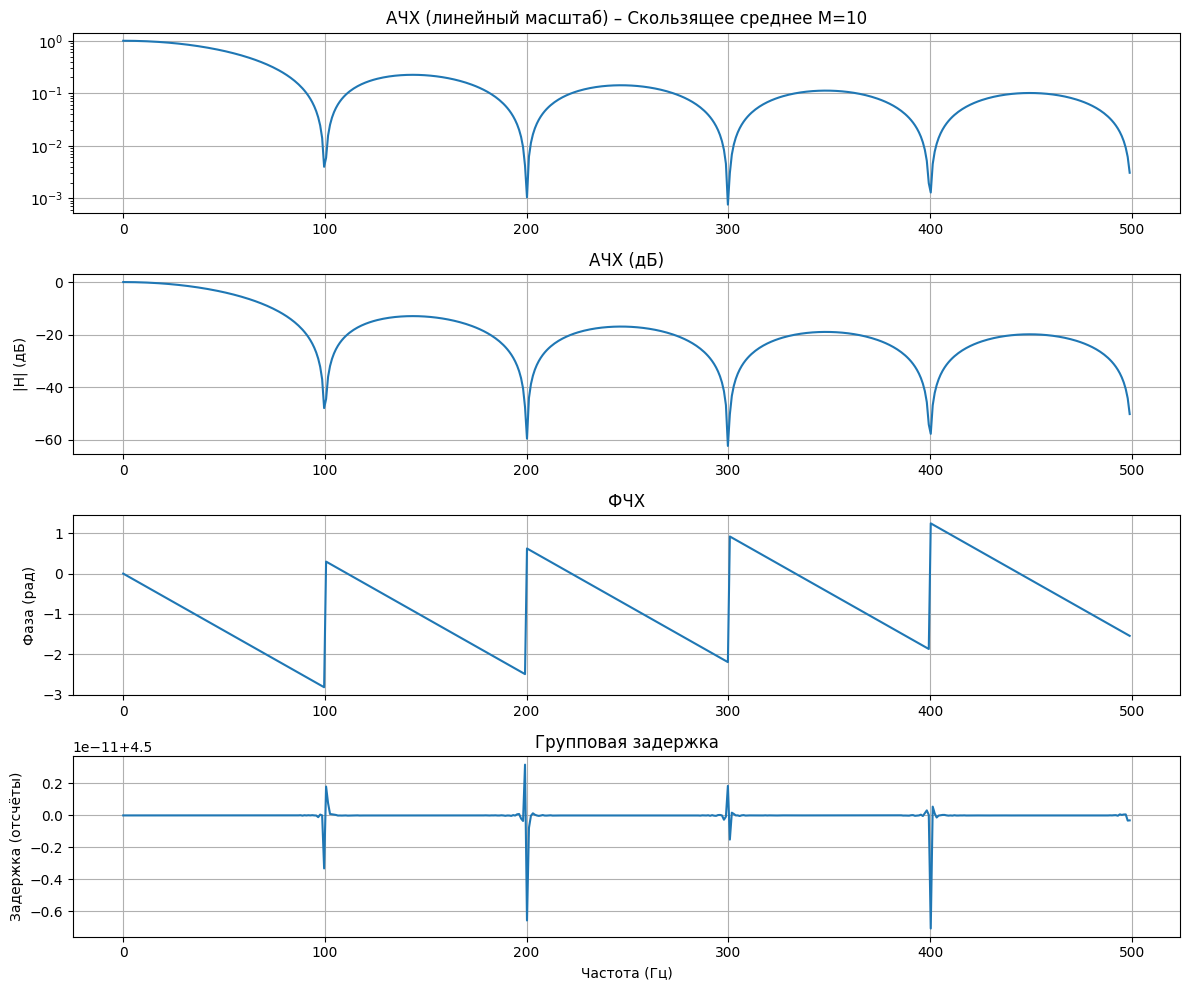

/tmp/ipykernel_18082/3306243778.py:17: UserWarning: The filter's denominator is extremely small at frequencies [1.571], around which a singularity may be present
  w_gd, gd = signal.group_delay((b, a), fs=fs)


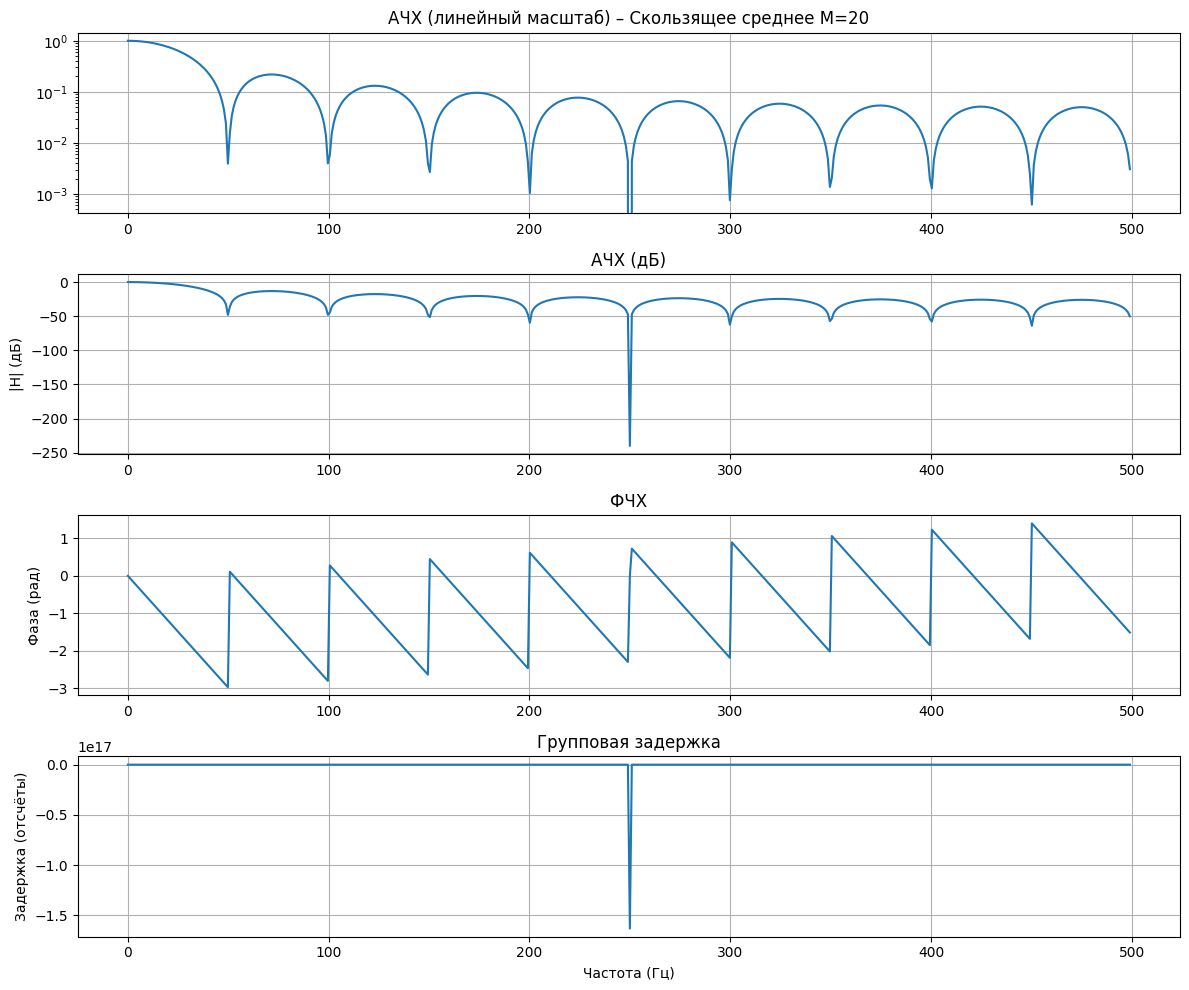

In [15]:
# Для M=5
b5 = np.ones(5)/5
plot_filter_response(b5, [1], fs=1000, title='Скользящее среднее M=5')

# Ваш код здесь: повторить для M=10 и M=20
b10 = np.ones(10)/10
plot_filter_response(b10, [1], fs=1000, title='Скользящее среднее M=10')

b20 = np.ones(20)/20
plot_filter_response(b20, [1], fs=1000, title='Скользящее среднее M=20')

**Вопрос:** Как изменение `M` влияет на крутизну среза АЧХ и на ФЧХ?


**Ответ:**
На АЧХ при увеличении M возрастает количество лепестков, а также увеличивается крутизна спада. \
На ФЧХ при увеличении M тоже становится больше участков и возрастает крутизна.

### Задание 1.3. Фильтрация суммы синусоид

Сгенерируйте сигнал длительностью 1 с (fs=1000 Гц): `x = sin(2π·10·t) + 0.5·sin(2π·100·t)`. Примените скользящее среднее с `M=5` и `M=20`. Постройте временные графики и спектры (амплитудный спектр через БПФ).


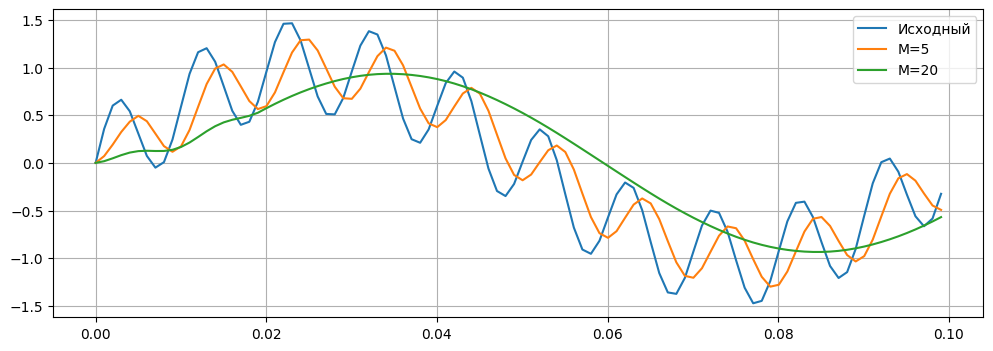

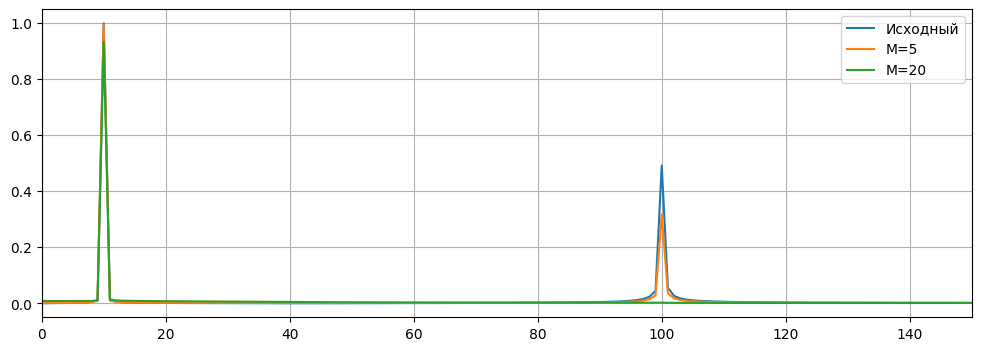

In [16]:
fs = 1000
t = np.linspace(0, 1, fs)
x = np.sin(2*np.pi*10*t) + 0.5*np.sin(2*np.pi*100*t)

M_array = [5, 10, 20]
b_5 = np.ones(M_array[0])/ M_array[0]
b_20 = np.ones(M_array[2])/ M_array[2]
x_5 = signal.lfilter(b_5, a, x)
x_20 = signal.lfilter(b_20, a, x)

plt.figure(figsize=(12,4))
plt.plot(t[:100], x[:100], label='Исходный')
plt.plot(t[:100], x_5[:100], label='M=5')
plt.plot(t[:100], x_20[:100], label='M=20')
plt.legend()
plt.grid()
plt.show()

# Спектры
def plot_spectrum(s, label):
    X = np.fft.fft(s)
    freq = np.fft.fftfreq(len(s), 1/fs)
    plt.plot(freq[:len(freq)//2], np.abs(X[:len(freq)//2])/(len(s)//2), label=label)

plt.figure(figsize=(12,4))
plot_spectrum(x, 'Исходный')
plot_spectrum(x_5, 'M=5')
plot_spectrum(x_20, 'M=20')
plt.xlim(0, 150)
plt.legend()
plt.grid()
plt.show()


**Вопрос:** Как значение `M` влияет на амплитуду 100 Гц сигнала? Объясните, почему так. Какая связь между АЧХ и результатом фильтрации?


**Ответ:**
При M=5 амплитуда сигнала 100 гц уменьшается, но не сильно. При M=20 амплитуда сигнала 100 гц падает до нуля. Это происходит из-за нулей АЧХ, возникающих на частотах $f_{null} = k \cdot \frac{f_s}{M}$, где $k = 1, 2, 3, ⋯$ \
$|Y(f)| = |X(f)| \cdot |H(f)|$ \
$|X(f)|$ — амплитуда гармоники на входе фильтра.\
$|H(f)|$ — значение АЧХ фильтра на этой конкретной частоте. \
$|Y(f)|$ — итоговая амплитуда гармоники на выходе.

## Часть 2. БИХ-фильтр: экспоненциальное сглаживание

Фильтр первого порядка: `y[n] = α x[n] + (1-α) y[n-1]`. Коэффициенты: `b = [α]`, `a = [1, -(1-α)]`.

### Задание 2.1. Реализация и характеристики

Для `α = 0.2`:
1. Постройте импульсную характеристику (50 отсчётов) и переходную характеристику.
2. Используя `plot_filter_response`, постройте АЧХ, ФЧХ и групповую задержку.


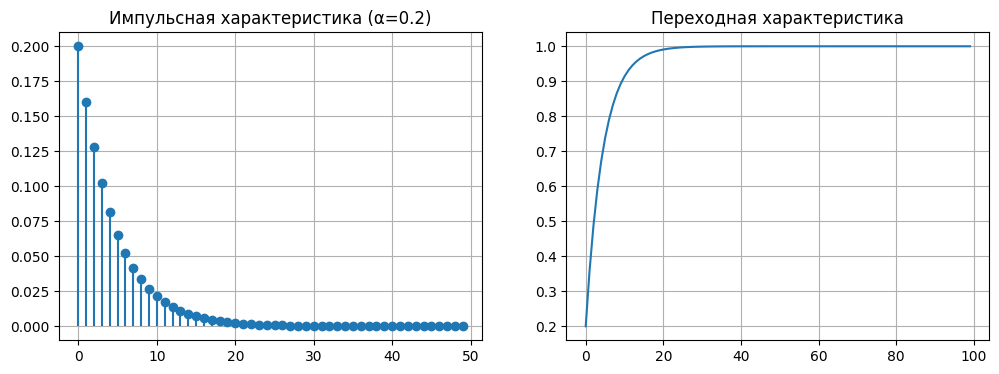

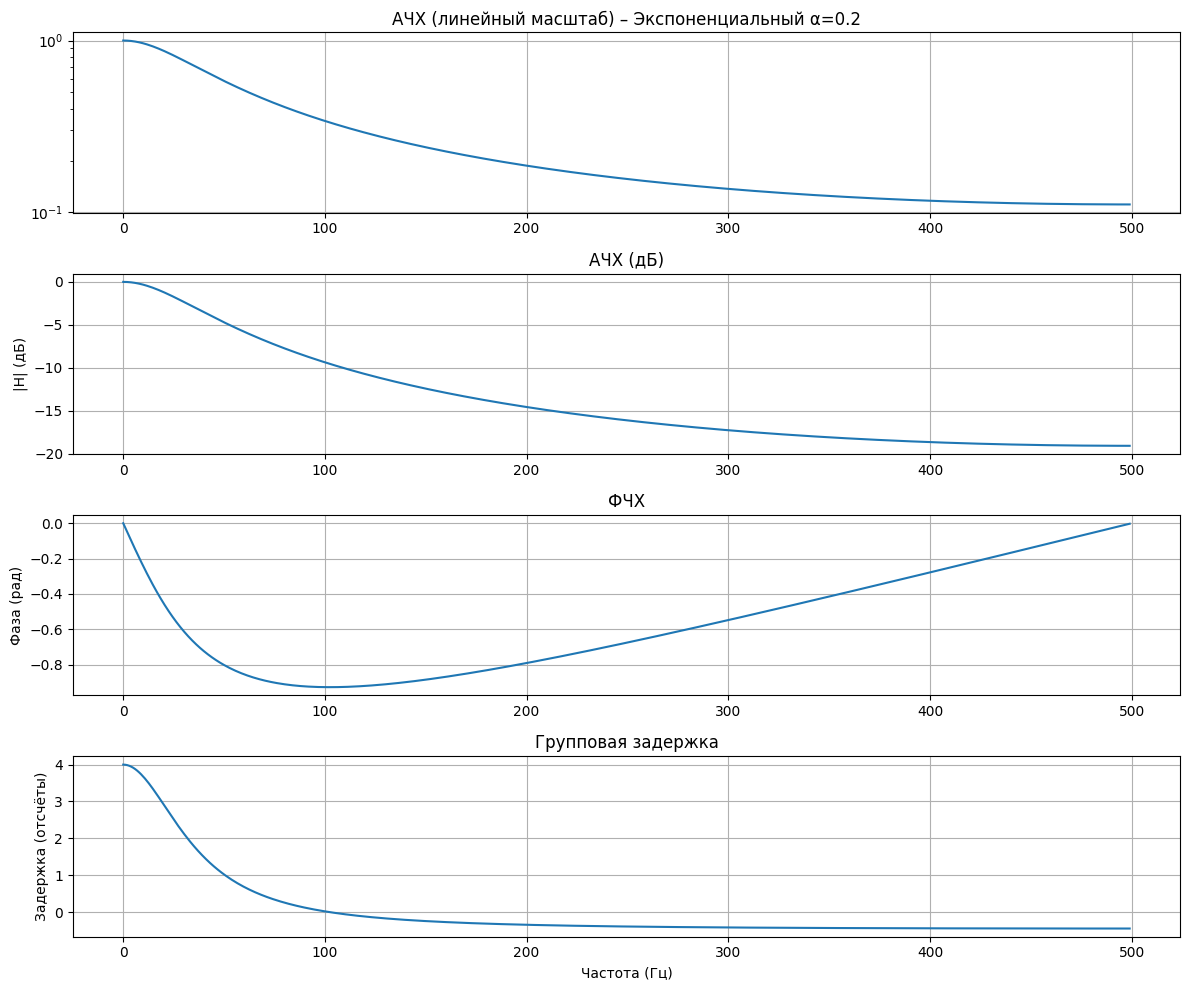

In [17]:
alpha = 0.2
b = [alpha]
a = [1, -(1-alpha)]

# Импульсная характеристика (длина 50)
impulse = np.zeros(50)
impulse[0] = 1
h = signal.lfilter(b, a, impulse)
# Переходная характеристика (длина 100)
step = np.ones(100)
s = signal.lfilter(b, a, step)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.stem(h, basefmt=" ")
plt.title(f'Импульсная характеристика (α={alpha})')
plt.grid()
plt.subplot(1,2,2)
plt.plot(s)
plt.title('Переходная характеристика')
plt.grid()
plt.show()

# Частотные характеристики
plot_filter_response(b, a, fs=1000, title=f'Экспоненциальный α={alpha}')


### Задание 2.2. Влияние параметра α

Исследуйте фильтр при `α = 0.05, 0.2, 0.8`. Постройте на одном графике АЧХ (в дБ) и на другом – групповую задержку. Сделайте выводы.


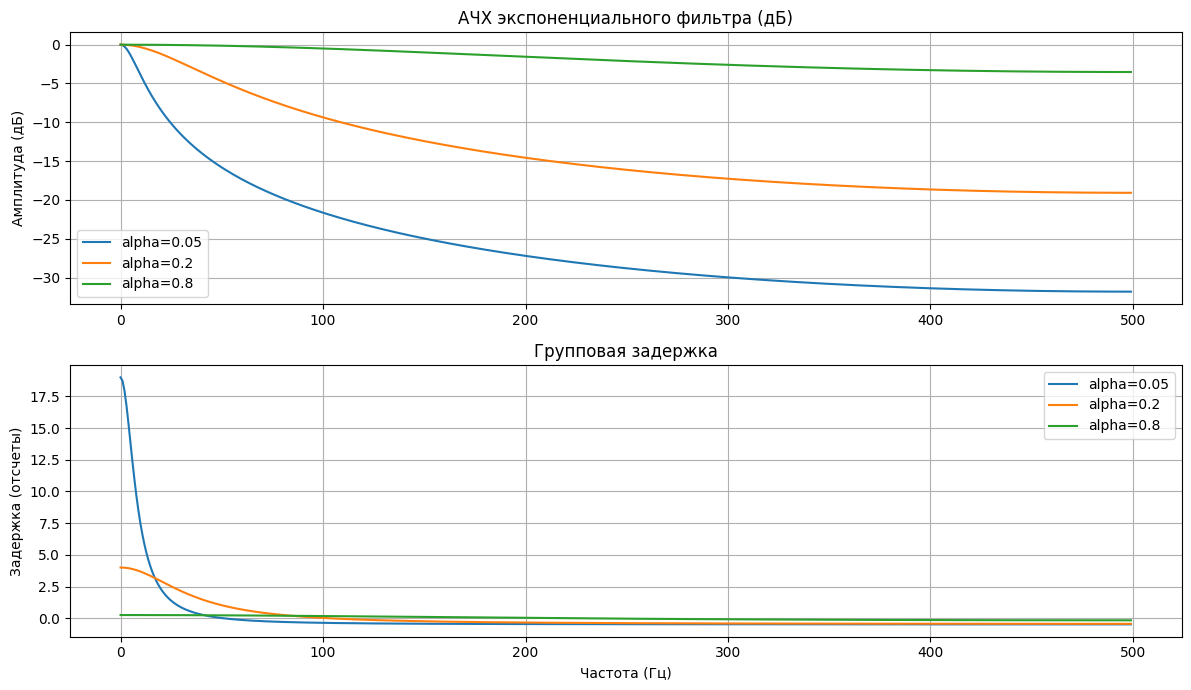

In [18]:
alphas = [0.05, 0.2, 0.8]
# Ваш код здесь: построить АЧХ (в дБ) и групповую задержку для всех α

plt.figure(figsize=(12, 7))
for a_val in alphas:
    b = [a_val]
    a = [1, -(1 - a_val)]

    w, H = signal.freqz(b, a, fs=1000)
    w_gd, gd = signal.group_delay((b, a), fs=1000)

    plt.subplot(2, 1, 1)
    plt.plot(w, 20*np.log10(np.abs(H) + 1e-12), label=f'alpha={a_val}')
    plt.subplot(2, 1, 2)
    plt.plot(w_gd, gd, label=f'alpha={a_val}')

plt.subplot(2, 1, 1)
plt.title('АЧХ экспоненциального фильтра (дБ)')
plt.ylabel('Амплитуда (дБ)')
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.title('Групповая задержка')
plt.xlabel('Частота (Гц)')
plt.ylabel('Задержка (отсчеты)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

**Вопрос:** Как α влияет на скорость реакции фильтра на изменение сигнала и на крутизну спада АЧХ?


**Ответ:**
Чем меньше альфа, тем медленнее фильтр реагирует на изменения сигнала (сильнее сглаживает и увеличивает задержку). Уменьшение альфа не меняет крутизну, а сдвигает частоту среза ниже.

### Задание 2.3. Фильтрация зашумлённого сигнала

Сгенерируйте сигнал: синусоида 20 Гц + белый шум (SNR ≈ 5 дБ), fs=500 Гц. Примените экспоненциальный фильтр с α = 0.1 и α = 0.5. Постройте исходный и отфильтрованные сигналы (первые 0.2 с). Сравните степень сглаживания и задержку.


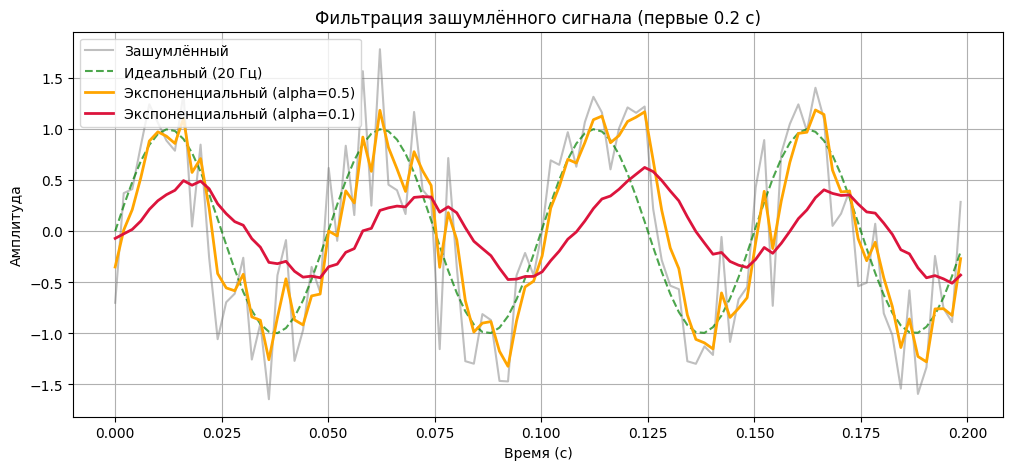

In [19]:
fs = 500
t = np.linspace(0, 1, fs)
x_clean = np.sin(2*np.pi*20*t)
noise = 0.5 * np.random.randn(len(t))
x_noisy = x_clean + noise

alpha1 = 0.1
b1 = [alpha1]
a1 = [1, -(1 - alpha1)]
y_01 = signal.lfilter(b1, a1, x_noisy)

alpha2 = 0.5
b2 = [alpha2]
a2 = [1, -(1 - alpha2)]
y_02 = signal.lfilter(b2, a2, x_noisy)

plt.figure(figsize=(12, 5))
plt.plot(t[:100], x_noisy[:100], 'gray', alpha=0.5, label='Зашумлённый')
plt.plot(t[:100], x_clean[:100], 'g--', alpha=0.7, label='Идеальный (20 Гц)')

plt.plot(t[:100], y_02[:100], color='orange', linewidth=2, label='Экспоненциальный (alpha=0.5)')
plt.plot(t[:100], y_01[:100], color='crimson', linewidth=2, label='Экспоненциальный (alpha=0.1)')

plt.title('Фильтрация зашумлённого сигнала (первые 0.2 с)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid()
plt.show()

**Вопрос:** Как на временных графиках проявляется групповая задержка, вносимая БИХ-фильтром?


**Ответ:**
График отфильтрованного сигнала сдвигается по оси времени вправо относительно исходного. Чем меньше альфа, тем заметнее этот сдвиг.

## Часть 3. Фильтр Савицкого – Голея (Savitzky–Golay)

Этот КИХ-фильтр основан на локальной полиномиальной регрессии. Он сохраняет форму сигнала (пики, перегибы) лучше, чем скользящее среднее.

### Задание 3.1. Базовое применение и влияние параметров

Сгенерируйте синусоиду 5 Гц (fs=100 Гц, длительность 2 с) и добавьте белый шум (дисперсия 0.2). Примените `savgol_filter` с параметрами:
- (window=11, polyorder=2)
- (window=21, polyorder=2)
- (window=11, polyorder=5)

Постройте исходный чистый сигнал, зашумлённый и три сглаженные версии. Объясните влияние параметров.


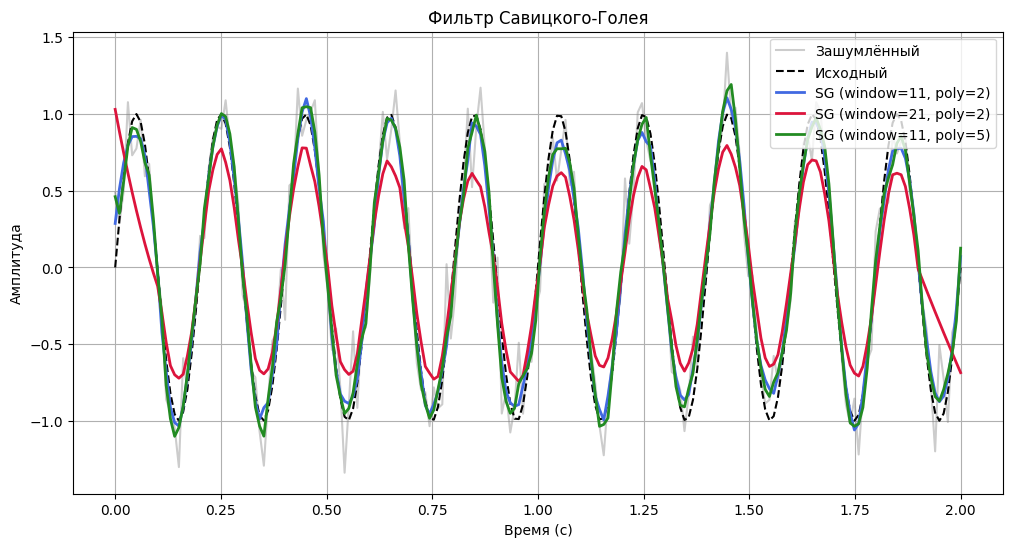

In [21]:
fs = 100
t = np.linspace(0, 2, 2*fs)
x_clean = np.sin(2*np.pi*5*t)
noise = 0.2 * np.random.randn(len(t))
x_noisy = x_clean + noise

y1 = savgol_filter(x_noisy, window_length=11, polyorder=2)
y2 = savgol_filter(x_noisy, window_length=21, polyorder=2)
y3 = savgol_filter(x_noisy, window_length=11, polyorder=5)

plt.figure(figsize=(12,6))
plt.plot(t, x_noisy, 'gray', alpha=0.4, label='Зашумлённый')
plt.plot(t, x_clean, 'k--', label='Исходный')

plt.plot(t, y1, color='royalblue', linewidth=2, label='SG (window=11, poly=2)')
plt.plot(t, y2, color='crimson', linewidth=2, label='SG (window=21, poly=2)')
plt.plot(t, y3, color='forestgreen', linewidth=2, label='SG (window=11, poly=5)')

plt.title('Фильтр Савицкого-Голея')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid()
plt.show()

**Вопрос 3.1:** Как увеличение `window_length` и увеличение `polyorder` влияют на степень сглаживания и сохранение формы сигнала?


**Ответ:**
При увелечении window_length cтепень сглаживания увеличивается. Сохранение формы сигнала ухудшается, т.к. чем шире окно, тем сложнее фиксированному полиному описать все локальные изгибы сигнала внутри него. \
При увеличении polyorder степень сглаживания уменьшается, а сохранение формы сигнала улучшается.

### Задание 3.2. Сравнение со скользящим средним

Создайте сигнал с острым пиком (гауссов импульс с σ=3) на фоне шума. Примените скользящее среднее (window=11) и Savitzky–Golay (window=11, polyorder=2). Сравните, какой фильтр лучше сохраняет форму пика.


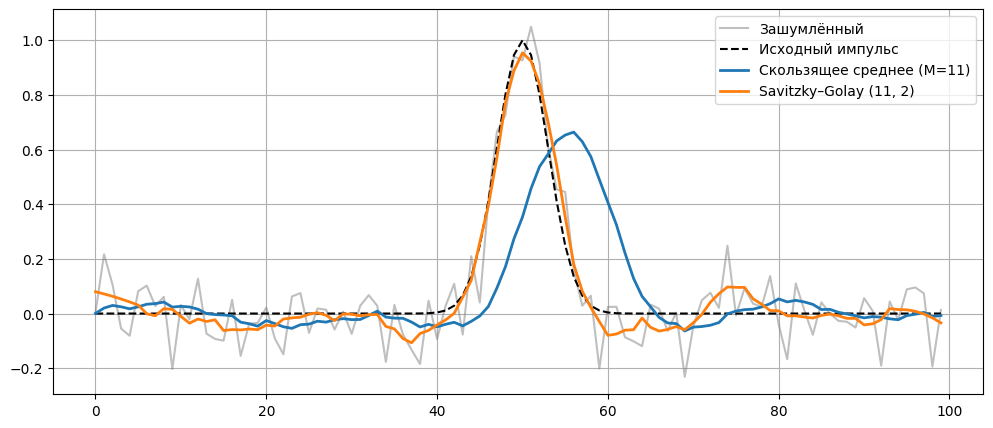

In [36]:
N = 100
x_pulse = np.zeros(N)
x_pulse[N//2] = 1
sigma = 3
gaussian = np.exp(-(np.arange(N)-N//2)**2/(2*sigma**2))
x_clean_pulse = gaussian / np.max(gaussian)
noise_pulse = 0.1 * np.random.randn(N)
x_noisy_pulse = x_clean_pulse + noise_pulse

b = np.ones(11) / 11
y_ma = signal.lfilter(b, [1], x_noisy_pulse)
y_sg = savgol_filter(x_noisy_pulse, window_length=11, polyorder=2)

plt.figure(figsize=(12,5))
plt.plot(x_noisy_pulse, 'gray', alpha=0.5, label='Зашумлённый')
plt.plot(x_clean_pulse, 'k--', label='Исходный импульс')

plt.plot(y_ma, label='Скользящее среднее (M=11)', linewidth=2)
plt.plot(y_sg, label='Savitzky–Golay (11, 2)', linewidth=2)
plt.legend()
plt.grid()
plt.show()


**Вопрос:** Какой из фильтров лучше сохраняет пик?


**Ответ:**
фильтр Савицкого-Голея сохраняет пик намного лучше

### Задание 3.3. Частотные характеристики

Получите коэффициенты Savitzky–Golay для `window_length=11, polyorder=2` с помощью `savgol_coeffs`. Нормируйте их так, чтобы сумма была равна 1. Постройте АЧХ этого фильтра и сравните с АЧХ скользящего среднего той же длины.


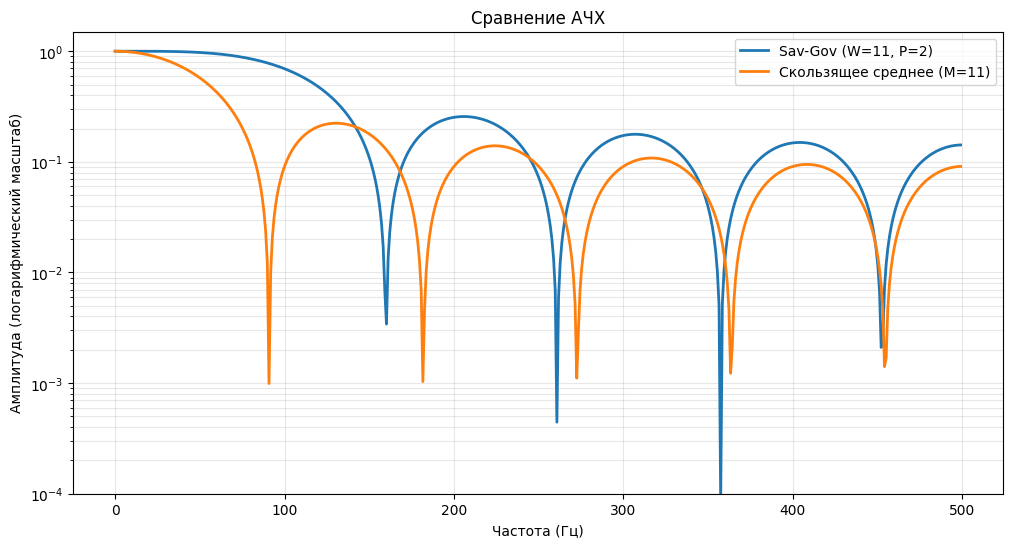

In [38]:
window_length = 11
polyorder = 2
coeffs = savgol_coeffs(window_length, polyorder)
coeffs = coeffs / np.sum(coeffs)


coeffs_sg = savgol_coeffs(window_length, polyorder)
coeffs_sg = coeffs_sg / np.sum(coeffs_sg)
coeffs_ma = np.ones(window_length) / window_length
w_sg, h_sg = signal.freqz(coeffs_sg, [1], fs=1000)
w_ma, h_ma = signal.freqz(coeffs_ma, [1], fs=1000)

plt.figure(figsize=(12, 6))
plt.semilogy(w_sg, np.abs(h_sg), label=f'Sav-Gov (W={window_length}, P={polyorder})', lw=2)
plt.semilogy(w_ma, np.abs(h_ma), label=f'Скользящее среднее (M={window_length})', lw=2)

plt.title('Сравнение АЧХ')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (логарифмический масштаб)')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.ylim(1e-4, 1.5)
plt.show()

**Вопрос:** Чем отличается АЧХ Savitzky–Golay от АЧХ скользящего среднего? Как это объясняет сохранение формы сигнала?

**Ответ:**
Скользящее среднее действительно сильнее подавляет высокие частоты и размывает сигнал. \
Savitzky–Golay намного лучше сохраняет амплитуду и форму из-за более широкой и плоской полосы пропускания на низких и средних частотах по сравнению со скользящим средним.

### Задание 3.4. Фильтрация меандра

Сгенерируйте меандр частотой 2 Гц (fs=500 Гц) и добавьте синусоидальную помеху 50 Гц амплитудой 0.5. Примените Savitzky–Golay (window=15, polyorder=3) и скользящее среднее (window=15). Сравните, как подавляется помеха и сохраняются фронты.


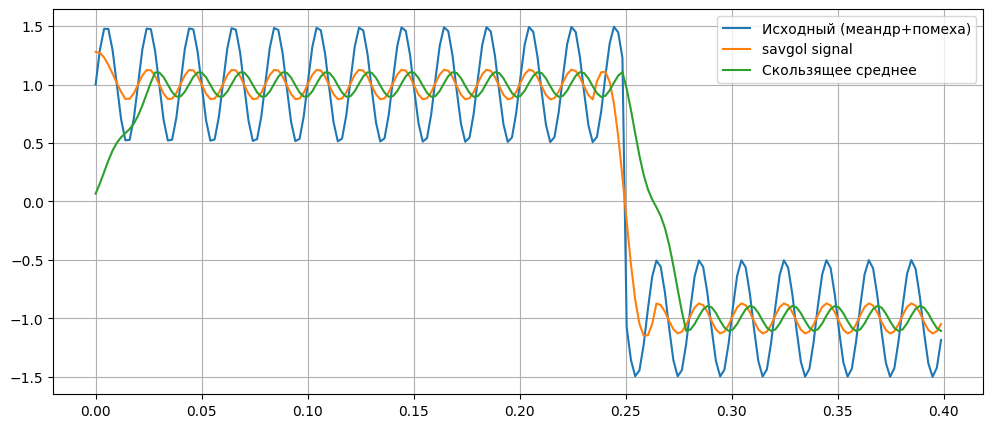

In [39]:
fs = 500
t = np.linspace(0, 1, fs)
meander = signal.square(2*np.pi*2*t)
interference = 0.5 * np.sin(2*np.pi*50*t)
x_meander = meander + interference

new_savgol_signal = savgol_filter(x_meander, window_length=15, polyorder=3)
b= np.ones(15) / 15
signal_s_avg = signal.lfilter(b, [1], x_meander)

plt.figure(figsize=(12,5))
plt.plot(t[:200], x_meander[:200], label='Исходный (меандр+помеха)')
plt.plot(t[:200], new_savgol_signal[:200], label='savgol signal')
plt.plot(t[:200], signal_s_avg[:200], label='Скользящее среднее')
plt.legend()
plt.grid()
plt.show()

**Вопрос:** Какой фильтр лучше подходит для обработки сигналов с резкими фронтами? Почему?


**Ответ:**
фильтр Савицкого-Голея подходит значительно лучше, так как он не размывает фронты и сохраняет форму импульса, в то время как скользящее среднее может округлять резкие переходы между уровнями

## Часть 4. Сравнение КИХ и БИХ фильтров

Для скользящего среднего (`M=10`), экспоненциального фильтра (`α=0.2`) и Savitzky–Golay (`win=11, polyorder=2`):

1. Постройте на одном графике их АЧХ (в дБ) и групповую задержку.
2. Подайте на них единичный импульс и единичный скачок, постройте реакции.
3. Сгенерируйте сигнал из прямоугольных импульсов с шумом (как в примере ниже) и примените все три фильтра. Оцените качество подавления шума и сохранения фронтов.


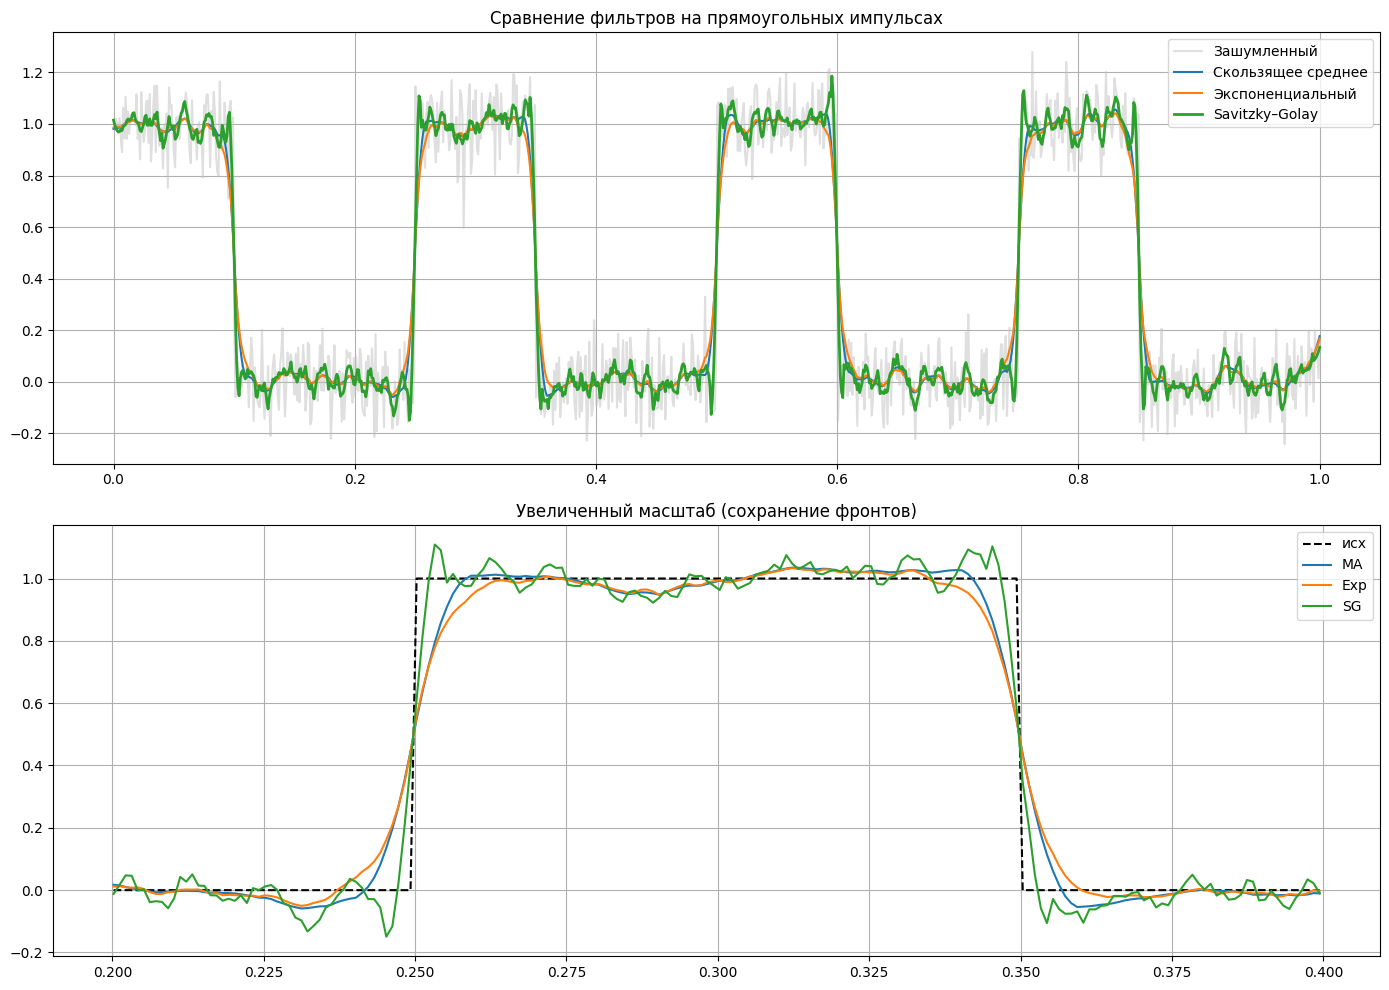

In [44]:
fs = 1000
t = np.linspace(0, 1, fs)
pulse_train = np.zeros_like(t)
pulse_train[0:100] = 1
pulse_train[250:350] = 1
pulse_train[500:600] = 1
pulse_train[750:850] = 1
noise = 0.1 * np.random.randn(len(t))
x_pulse_noisy = pulse_train + noise

# Ваш код здесь: определить коэффициенты фильтров (M=10, alpha=0.2, sg coeffs)
b_ma = np.ones(10) / 10
a_ma = [1]

alpha = 0.2
b_exp = [alpha]
a_exp = [1, -(1 - alpha)]

# Ваш код здесь: отфильтровать x_pulse_noisy каждым фильтром
x_ma = signal.filtfilt(b_ma, a_ma, x_pulse_noisy)
x_exp = signal.filtfilt(b_exp, a_exp, x_pulse_noisy)
x_sg = signal.savgol_filter(x_pulse_noisy, window_length=11, polyorder=2)

# Ваш код здесь: построить графики (исходный + три отфильтрованных)
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(t, x_pulse_noisy, color='silver', alpha=0.5, label='Зашумленный')
plt.plot(t, x_ma, label='Скользящее среднее', linewidth=1.5)
plt.plot(t, x_exp, label='Экспоненциальный', linewidth=1.5)
plt.plot(t, x_sg, label='Savitzky–Golay', linewidth=2)
plt.title('Сравнение фильтров на прямоугольных импульсах')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t[200:400], pulse_train[200:400], 'k--', label='исх')
plt.plot(t[200:400], x_ma[200:400], label='MA')
plt.plot(t[200:400], x_exp[200:400], label='Exp')
plt.plot(t[200:400], x_sg[200:400], label='SG')
plt.title('Увеличенный масштаб (сохранение фронтов)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Вопрос:** Какой фильтр обеспечивает наилучшее подавление шума? Какой лучше сохраняет фронты? Какой имеет наименьшие фазовые искажения?


**Ответ:**
Наилучшее подавление шума обеспечивает скользящее среднее. \
Savitzky–Golay лучше сохраняет фронты. \
Наименьшие фазовые искажения дает Savitzky–Golay.

